0. Import the data and declare your package dependencies.

In [2]:
import pandas as pd

In [ ]:
df_avocado = pd.read_csv("Labs/Lab_2/Lab_2_Data/avocado-updated-2020.csv")

df_avocado.head()

,date,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,geography
0,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.0,conventional,2015,Albany
1,2015-01-04,1.79,1373.95,57.42,153.88,0.00,1162.65,1162.65,0.00,0.0,organic,2015,Albany
2,2015-01-04,1.00,435021.49,364302.39,23821.16,82.15,46815.79,16707.15,30108.64,0.0,conventional,2015,Atlanta
3,2015-01-04,1.76,3846.69,1500.15,938.35,0.00,1408.19,1071.35,336.84,0.0,organic,2015,Atlanta
4,2015-01-04,1.08,788025.06,53987.31,552906.04,39995.03,141136.68,137146.07,3990.61,0.0,conventional,2015,Baltimore/Washington


1. Briefly describe the data set. What information does it contain?

The data set contains 13 variables with weekly avocado retil data. It includes the date, average price, total volume sold, sales by PLU, bag sizes, avacado type, year, and geographic region. 


In [4]:
df_avocado.columns

Index(['date', 'average_price', 'total_volume', '4046', '4225', '4770',
       'total_bags', 'small_bags', 'large_bags', 'xlarge_bags', 'type', 'year',
       'geography'],
      dtype='object')

2. Clean the data in any way you see fit.

In [5]:
df_avocado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33045 entries, 0 to 33044
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           33045 non-null  object 
 1   average_price  33045 non-null  float64
 2   total_volume   33045 non-null  float64
 3   4046           33045 non-null  float64
 4   4225           33045 non-null  float64
 5   4770           33045 non-null  float64
 6   total_bags     33045 non-null  float64
 7   small_bags     33045 non-null  float64
 8   large_bags     33045 non-null  float64
 9   xlarge_bags    33045 non-null  float64
 10  type           33045 non-null  object 
 11  year           33045 non-null  int64  
 12  geography      33045 non-null  object 
dtypes: float64(9), int64(1), object(3)
memory usage: 3.3+ MB


In [6]:
df_avocado.isna().sum()

date             0
average_price    0
total_volume     0
4046             0
4225             0
4770             0
total_bags       0
small_bags       0
large_bags       0
xlarge_bags      0
type             0
year             0
geography        0
dtype: int64

In [7]:
df_avocado.duplicated().sum()

np.int64(0)

In [9]:
df_avocado["date"] = pd.to_datetime(df_avocado["date"])

df_avocado = df_avocado.rename(columns={"4046": "small_avocado_volume", "4225": "large_avocado_volume", "4770": "xlarge_avocado_volume"})

In [10]:
df_avocado["geography"].nunique()

54

In [11]:
sorted(df_avocado["geography"].unique())

['Albany',
 'Atlanta',
 'Baltimore/Washington',
 'Boise',
 'Boston',
 'Buffalo/Rochester',
 'California',
 'Charlotte',
 'Chicago',
 'Cincinnati/Dayton',
 'Columbus',
 'Dallas/Ft. Worth',
 'Denver',
 'Detroit',
 'Grand Rapids',
 'Great Lakes',
 'Harrisburg/Scranton',
 'Hartford/Springfield',
 'Houston',
 'Indianapolis',
 'Jacksonville',
 'Las Vegas',
 'Los Angeles',
 'Louisville',
 'Miami/Ft. Lauderdale',
 'Midsouth',
 'Nashville',
 'New Orleans/Mobile',
 'New York',
 'Northeast',
 'Northern New England',
 'Orlando',
 'Philadelphia',
 'Phoenix/Tucson',
 'Pittsburgh',
 'Plains',
 'Portland',
 'Raleigh/Greensboro',
 'Richmond/Norfolk',
 'Roanoke',
 'Sacramento',
 'San Diego',
 'San Francisco',
 'Seattle',
 'South Carolina',
 'South Central',
 'Southeast',
 'Spokane',
 'St. Louis',
 'Syracuse',
 'Tampa',
 'Total U.S.',
 'West',
 'West Tex/New Mexico']

In [12]:
major_regions = ["Great Lakes", "Midsouth", "Northeast", "Northern New England",
    "Plains", "South Central", "Southeast", "West"]
states = ["California", "South Carolina"]

def classify_geography(x):
    if x == "Total U.S.":
        return "National"
    elif x in major_regions:
        return "Major Region"
    elif x in states:
        return "State"
    else:
        return "Metro"

df_avocado["geography_type"] = df_avocado["geography"].apply(classify_geography)

In [13]:
df_avocado["geography_type"] = df_avocado["geography"].apply(classify_geography)

In [14]:
df_avocado[["geography", "geography_type"]].drop_duplicates().sort_values("geography_type")

,geography,geography_type
104,West,Major Region
58,Northeast,Major Region
60,Northern New England,Major Region
92,Southeast,Major Region
90,South Central,Major Region
70,Plains,Major Region
30,Great Lakes,Major Region
50,Midsouth,Major Region
54,New Orleans/Mobile,Metro
56,New York,Metro


3. Which major geographical region sold the most total organic, small Hass avocados in 2017?

In [15]:
q3 = df_avocado[(df_avocado["geography_type"] == "Major Region")
 & (df_avocado["year"] == 2017) 
 & (df_avocado["type"] == "organic")]

In [16]:
q3.groupby("geography")["small_avocado_volume"].sum().sort_values(ascending=False)

geography
West                    1870206.29
South Central           1717104.19
Northeast                925832.36
Southeast                285124.34
Great Lakes              202487.68
Midsouth                 186395.50
Plains                   168583.40
Northern New England       1249.48
Name: small_avocado_volume, dtype: float64

West sold the total organic small Hass avocados in 2017 out of the major geographical regions

4. Split the date variable into month, day, and year variables. In which month is the highest average volume of avocado sales?

In [17]:
df_avocado["month"] = df_avocado["date"].dt.month
df_avocado["day"] = df_avocado["date"].dt.day
df_avocado["year_from_date"] = df_avocado["date"].dt.year

In [18]:
df_avocado.groupby("month")["total_volume"].mean().sort_values(ascending=False)

month
5     1.123632e+06
2     1.095374e+06
6     1.051247e+06
4     1.016582e+06
3     9.957150e+05
1     9.853122e+05
7     9.832681e+05
8     9.499249e+05
9     9.064773e+05
10    8.446863e+05
11    8.223470e+05
12    8.076695e+05
Name: total_volume, dtype: float64

May had the highest average volume of avocado sales.

5. Which metro area geographical regions sold the most total avocados? Plot side-by-side box-plots of the total volume for only the five metro geographical regions with the highest averages for the total_volume variable.

In [19]:
metro_df = df_avocado[df_avocado["geography_type"] == "Metro"]


In [20]:
top5_metros = (metro_df.groupby("geography")["total_volume"]
.mean()
.sort_values(ascending=False)
.head(5))
top5_metros

geography
Los Angeles         1.567566e+06
New York            8.631458e+05
Dallas/Ft. Worth    7.127519e+05
Houston             6.876533e+05
Phoenix/Tucson      6.250383e+05
Name: total_volume, dtype: float64

In [ ]:
top5_names = top5_metros.index

metro_top5 = metro_df[metro_df["geography"].isin(top5_names)].copy()

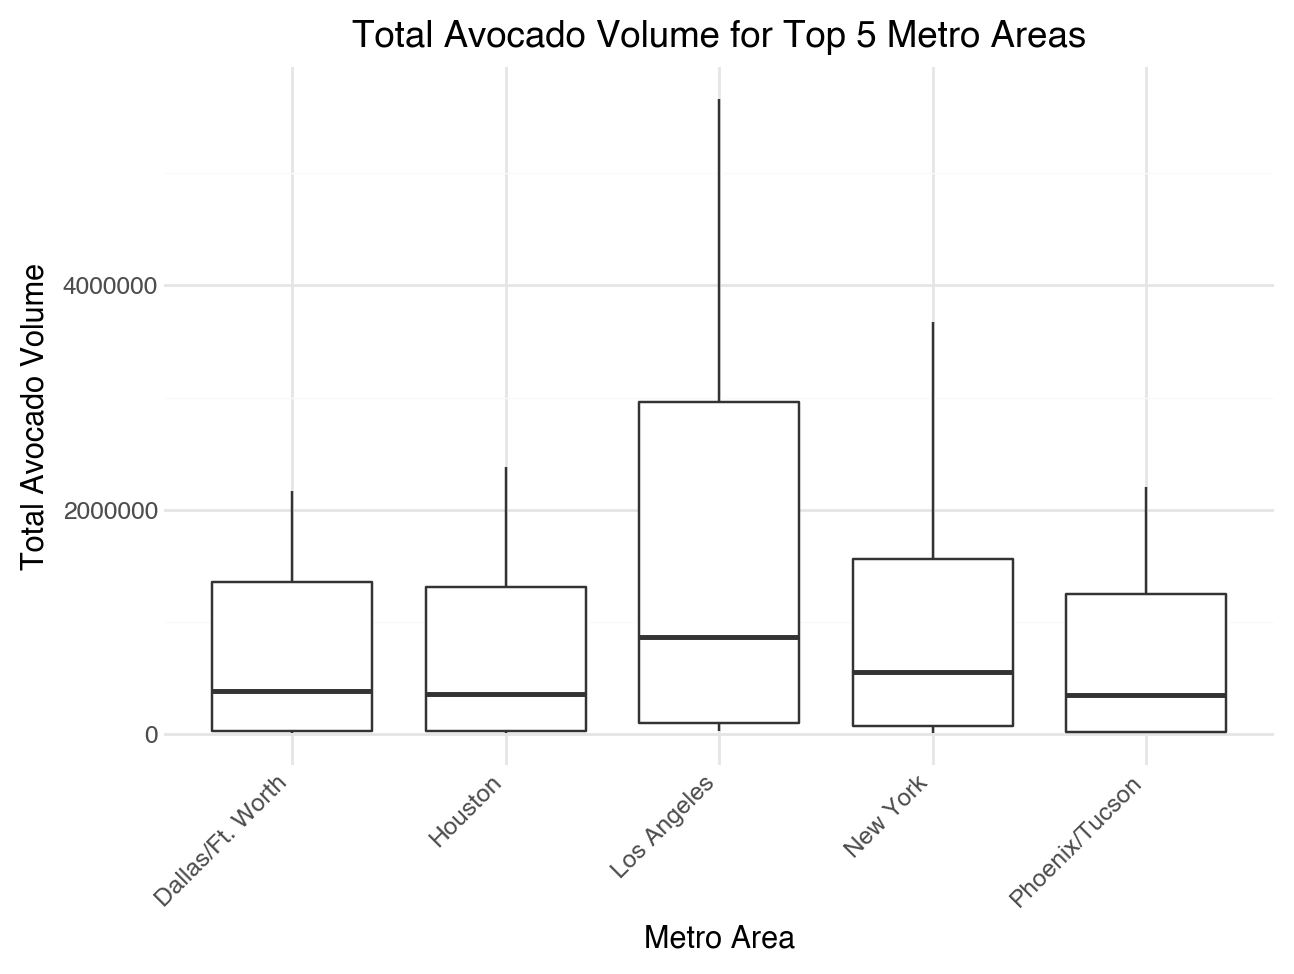

In [23]:
from plotnine import *

(ggplot(metro_top5, aes(x="geography", y="total_volume"))
+ geom_boxplot()
+ labs(x="Metro Area", y="Total Avocado Volume", title="Total Avocado Volume for Top 5 Metro Areas")
+ theme_minimal()
+ theme(axis_text_x=element_text(rotation=45, ha="right")))

The five metro areas with the highest average total avocado volume were Los Angeles, New York, Houston, Dallas/Ft. Worth, and Phoenix/Tucson. Los Angeles generally had the highest sales volume and the widest spread among these metro areas.

6. From your cleaned data set, create a data set with only these California regions and answer the following questions about these California regions only.

In [24]:
california_regions = ["Los Angeles", "San Diego", "Sacramento", "San Francisco"]

df_california = df_avocado[df_avocado["geography"].isin(california_regions)].copy()

In [25]:
df_california["geography"].unique()

array(['Los Angeles', 'Sacramento', 'San Diego', 'San Francisco'], dtype=object)

In [26]:
df_california.shape

(2448, 17)

7. In which California regions is the price of organic versus conventional avocados most different? Support your answer with a few summary statistics AND a visualization.

In [27]:
price_summary = (df_california.groupby(["geography", "type"])["average_price"]
.mean()
.reset_index())

price_summary

,geography,type,average_price
0,Los Angeles,conventional,1.047124
1,Los Angeles,organic,1.574902
2,Sacramento,conventional,1.295359
3,Sacramento,organic,1.873856
4,San Diego,conventional,1.113856
5,San Diego,organic,1.798366
6,San Francisco,conventional,1.400490
7,San Francisco,organic,2.119444


In [28]:
price_wide = price_summary.pivot(index="geography", columns="type", values="average_price")

price_wide

type,conventional,organic
geography,,
Los Angeles,1.047124,1.574902
Sacramento,1.295359,1.873856
San Diego,1.113856,1.798366
San Francisco,1.400490,2.119444


In [29]:
price_wide["price_difference"] = (price_wide["organic"] - price_wide["conventional"])

price_wide.sort_values("price_difference", ascending=False)

type,conventional,organic,price_difference
geography,,,
San Francisco,1.400490,2.119444,0.718954
San Diego,1.113856,1.798366,0.684510
Sacramento,1.295359,1.873856,0.578497
Los Angeles,1.047124,1.574902,0.527778


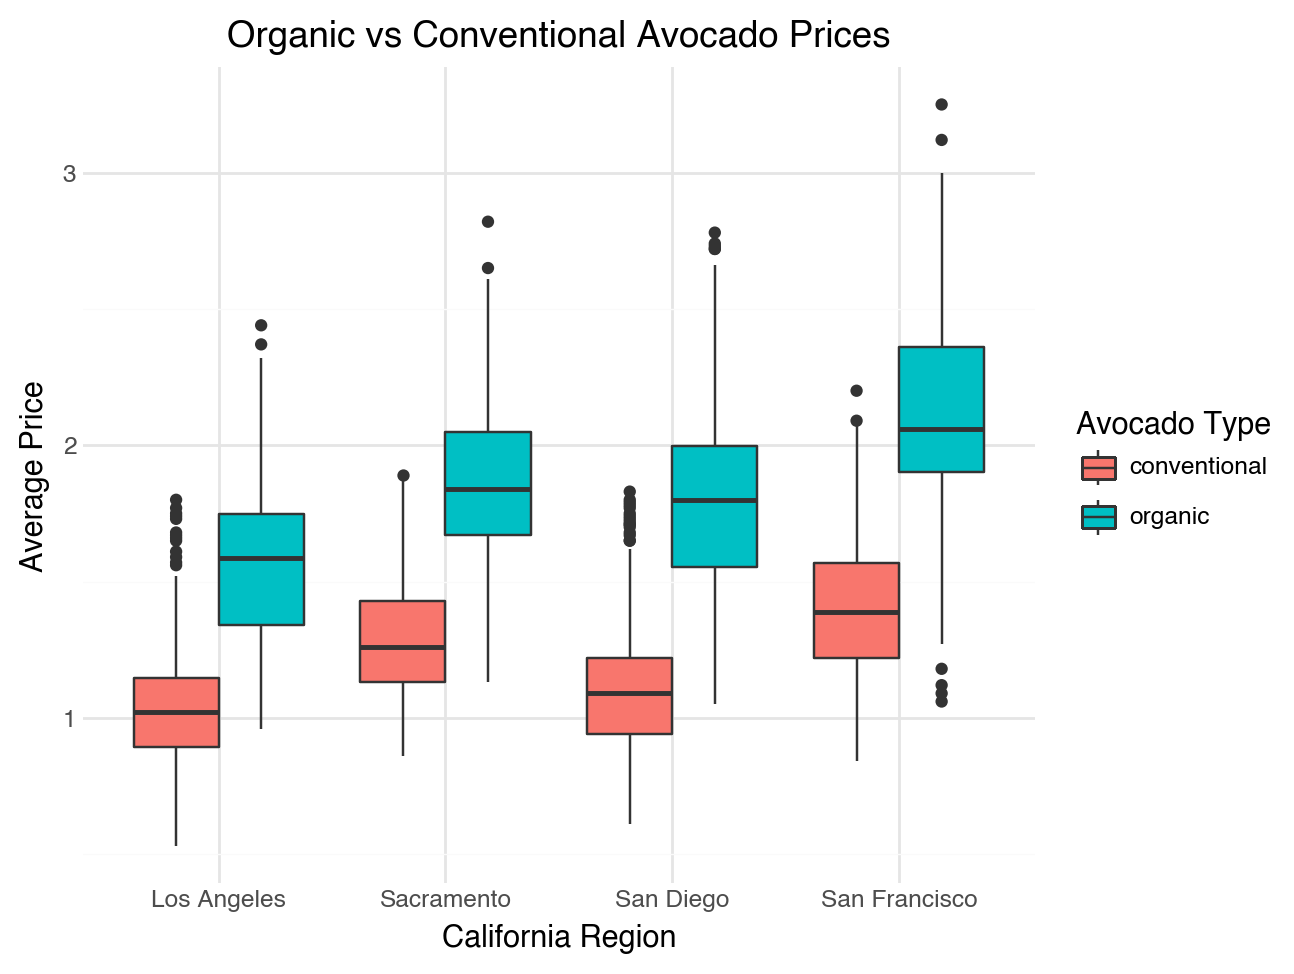

In [30]:
from plotnine import *

(ggplot(df_california, aes(x="geography", y="average_price", fill="type"))
+ geom_boxplot(position="dodge")
+ labs(x="California Region", y="Average Price", fill="Avocado Type", title="Organic vs Conventional Avocado Prices")
+ theme_minimal())

San Francisco had the largest difference between organic and conventional avocado prices. The average organic price was about $2.12 compared with about $1.40 for conventional avocados, a difference of approximately $0.72. The boxplot also shows the greatest separation between the two price distributions in San Francisco.

8. The following plot shows, for all four California regions, the proportion of the average Hass avocado sales that are small, large, or extra large; conventional vs. organic. Recreate the plot; you do not have to replicate the exact finishing touches - e.g., color, theme - but your plot should resemble the content of this plot.

In [31]:
size_summary = (df_california.groupby(["geography", "type"])[["small_avocado_volume", "large_avocado_volume", "xlarge_avocado_volume"]]
.mean()
.reset_index())

size_summary

,geography,type,small_avocado_volume,large_avocado_volume,xlarge_avocado_volume
0,Los Angeles,conventional,1.172952e+06,443842.308562,97073.643529
1,Los Angeles,organic,1.444206e+04,20804.220654,6.035294
2,Sacramento,conventional,1.412831e+05,243005.070163,6333.279673
3,Sacramento,organic,2.808893e+03,4282.693203,0.772680
4,San Diego,conventional,1.637928e+05,140106.101438,17963.543497
5,San Diego,organic,2.573068e+03,7273.784575,1.323595
6,San Francisco,conventional,2.158398e+05,449377.420359,14931.603235
7,San Francisco,organic,8.303041e+03,11350.098072,2.159346


In [32]:
size_long = size_summary.melt(id_vars=["geography", "type"],
value_vars=["small_avocado_volume", "large_avocado_volume", "xlarge_avocado_volume"],
var_name="size",
value_name="average_volume")

size_long.head()

,geography,type,size,average_volume
0,Los Angeles,conventional,small_avocado_volume,1.172952e+06
1,Los Angeles,organic,small_avocado_volume,1.444206e+04
2,Sacramento,conventional,small_avocado_volume,1.412831e+05
3,Sacramento,organic,small_avocado_volume,2.808893e+03
4,San Diego,conventional,small_avocado_volume,1.637928e+05


In [33]:
size_long["proportion"] = (size_long["average_volume"] / size_long.groupby(["geography", "type"])["average_volume"].transform("sum"))

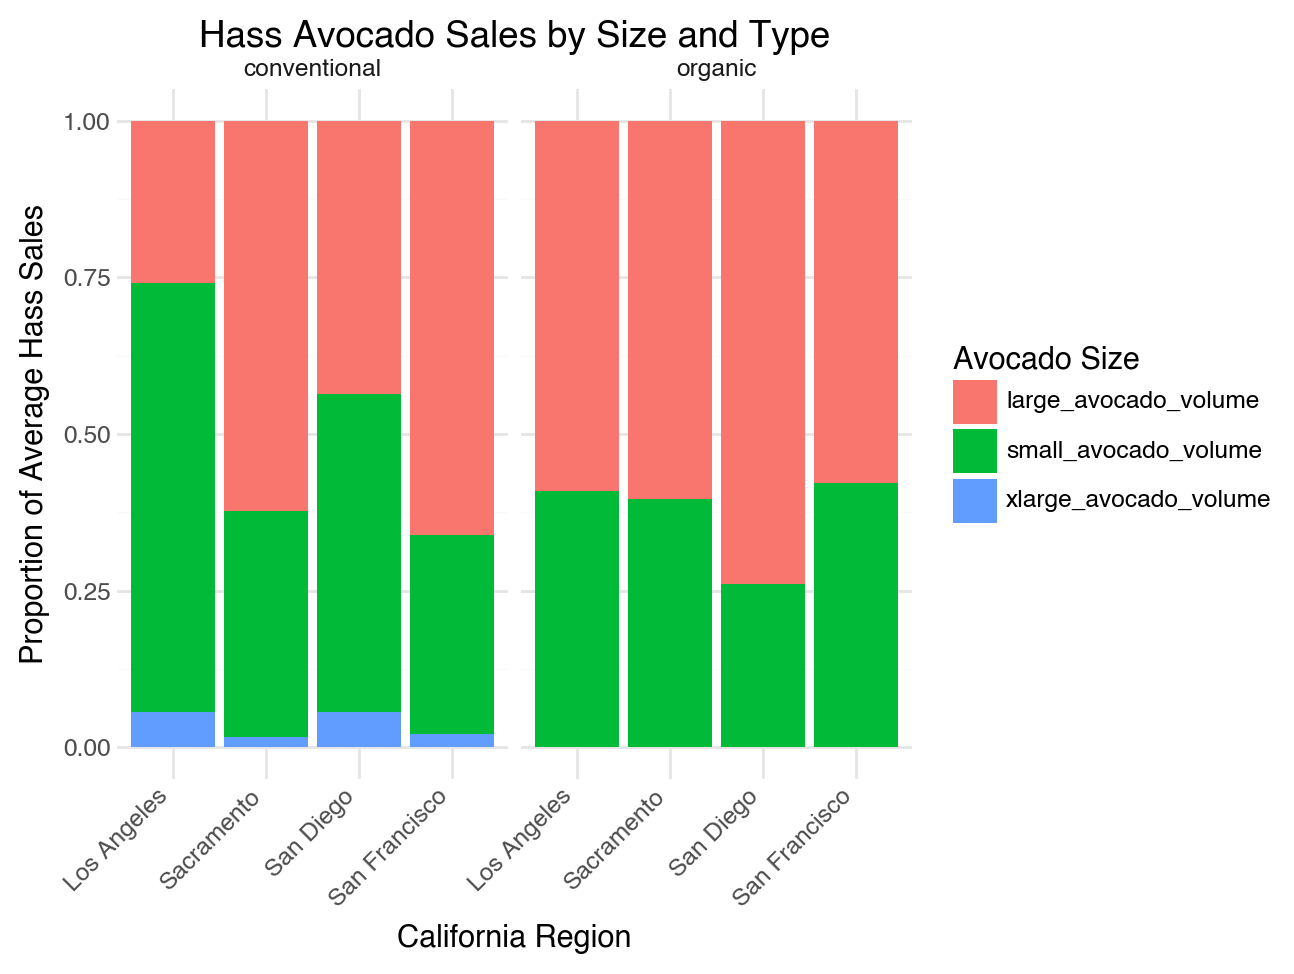

In [34]:
(ggplot(size_long, aes(x="geography", y="proportion", fill="size"))
+ geom_col()
+ facet_wrap("type")
+ labs(x="California Region", y="Proportion of Average Hass Sales", fill="Avocado Size", title="Hass Avocado Sales by Size and Type")
+ theme_minimal()
+ theme(axis_text_x=element_text(rotation=45, ha="right")))

Using Outside Data

In [41]:
df_housing = pd.read_csv(
    "Labs/Lab_2/Lab_2_Data/Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv"
)

df_housing.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30,2026-05-31,2026-06-30,2026-07-31
0,102001,0,United States,country,NaN,124760.353386,124979.846843,125252.051048,125835.875637,126507.787743,...,368600.830990,369290.109714,370096.503345,370865.855786,371594.025445,372094.225425,372175.152586,371910.603335,371664.627433,371774.013984
1,394913,1,"New York, NY",msa,NY,221730.961420,222673.192902,223624.151144,225551.160519,227546.645459,...,711084.998310,714481.548049,717957.123329,721070.448456,724701.411953,728550.827603,730998.279366,732547.901292,734053.602437,737078.239973
2,753899,2,"Los Angeles, CA",msa,CA,225112.633581,225950.338198,227066.152759,229286.248907,231714.338088,...,958467.862334,961838.271934,965861.431836,968431.823262,969683.356261,969344.133347,967696.188085,966216.924715,964714.939801,964933.539367
3,394463,3,"Chicago, IL",msa,IL,158537.235557,158683.994854,158963.500519,159658.841153,160495.252299,...,347939.585960,349538.582140,351328.450802,353002.256461,354806.848210,356259.214604,357291.377201,357923.452730,358804.309842,360261.570973
4,394514,4,"Dallas, TX",msa,TX,131282.417502,131340.891150,131408.112593,131582.679622,131812.841469,...,372246.711434,371975.510588,371751.570814,371305.648235,370713.999305,369629.029256,368279.710153,366682.370547,365420.503097,364792.581562


In [42]:
housing_ca = df_housing[df_housing["RegionName"].isin(["Los Angeles, CA", "San Diego, CA", "Sacramento, CA", "San Francisco, CA"])].copy()

housing_ca[["RegionName", "StateName"]]

,RegionName,StateName
2,"Los Angeles, CA",CA
12,"San Francisco, CA",CA
17,"San Diego, CA",CA
26,"Sacramento, CA",CA


In [43]:
housing_long = housing_ca.melt(id_vars=["RegionName"], var_name="date", value_name="home_value")

housing_long.head()

,RegionName,date,home_value
0,"Los Angeles, CA",RegionID,753899
1,"San Francisco, CA",RegionID,395057
2,"San Diego, CA",RegionID,395056
3,"Sacramento, CA",RegionID,395045
4,"Los Angeles, CA",SizeRank,2


In [44]:
date_cols = [col for col in df_housing.columns
    if col.startswith(("2015-", "2016-", "2017-", "2018-", "2019-", "2020-"))]

housing_long = housing_ca.melt(
    id_vars=["RegionName"],
    value_vars=date_cols,
    var_name="date",
    value_name="home_value")

In [45]:
housing_long["date"] = pd.to_datetime(housing_long["date"])
housing_long["year"] = housing_long["date"].dt.year

In [46]:
housing_yearly = (housing_long.groupby(["RegionName", "year"])["home_value"]
    .mean()
    .reset_index())

housing_yearly

,RegionName,year,home_value
0,"Los Angeles, CA",2015,514580.473105
1,"Los Angeles, CA",2016,534222.622398
2,"Los Angeles, CA",2017,581681.884000
3,"Los Angeles, CA",2018,642491.469984
4,"Los Angeles, CA",2019,658471.806482
5,"Los Angeles, CA",2020,692474.863353
6,"Sacramento, CA",2015,332847.331553
7,"Sacramento, CA",2016,361279.764759
8,"Sacramento, CA",2017,391854.312653
9,"Sacramento, CA",2018,422019.023416


In [47]:
housing_yearly["geography"] = housing_yearly["RegionName"].replace({
    "Los Angeles, CA": "Los Angeles",
    "San Diego, CA": "San Diego",
    "Sacramento, CA": "Sacramento",
    "San Francisco, CA": "San Francisco"
})

In [48]:
avocado_yearly = (df_california.groupby(["geography", "year"])["average_price"]
    .mean()
    .reset_index())

avocado_yearly

,geography,year,average_price
0,Los Angeles,2015,1.152500
1,Los Angeles,2016,1.083750
2,Los Angeles,2017,1.377358
3,Los Angeles,2018,1.385000
4,Los Angeles,2019,1.482019
5,Los Angeles,2020,1.394896
6,Sacramento,2015,1.454038
7,Sacramento,2016,1.668173
8,Sacramento,2017,1.774057
9,Sacramento,2018,1.498776


In [49]:
joined_df = avocado_yearly.merge(housing_yearly[["geography", "year", "home_value"]],
on=["geography", "year"],
how="inner")

joined_df

,geography,year,average_price,home_value
0,Los Angeles,2015,1.152500,514580.473105
1,Los Angeles,2016,1.083750,534222.622398
2,Los Angeles,2017,1.377358,581681.884000
3,Los Angeles,2018,1.385000,642491.469984
4,Los Angeles,2019,1.482019,658471.806482
5,Los Angeles,2020,1.394896,692474.863353
6,Sacramento,2015,1.454038,332847.331553
7,Sacramento,2016,1.668173,361279.764759
8,Sacramento,2017,1.774057,391854.312653
9,Sacramento,2018,1.498776,422019.023416


In [50]:
joined_df

,geography,year,average_price,home_value
0,Los Angeles,2015,1.152500,514580.473105
1,Los Angeles,2016,1.083750,534222.622398
2,Los Angeles,2017,1.377358,581681.884000
3,Los Angeles,2018,1.385000,642491.469984
4,Los Angeles,2019,1.482019,658471.806482
5,Los Angeles,2020,1.394896,692474.863353
6,Sacramento,2015,1.454038,332847.331553
7,Sacramento,2016,1.668173,361279.764759
8,Sacramento,2017,1.774057,391854.312653
9,Sacramento,2018,1.498776,422019.023416


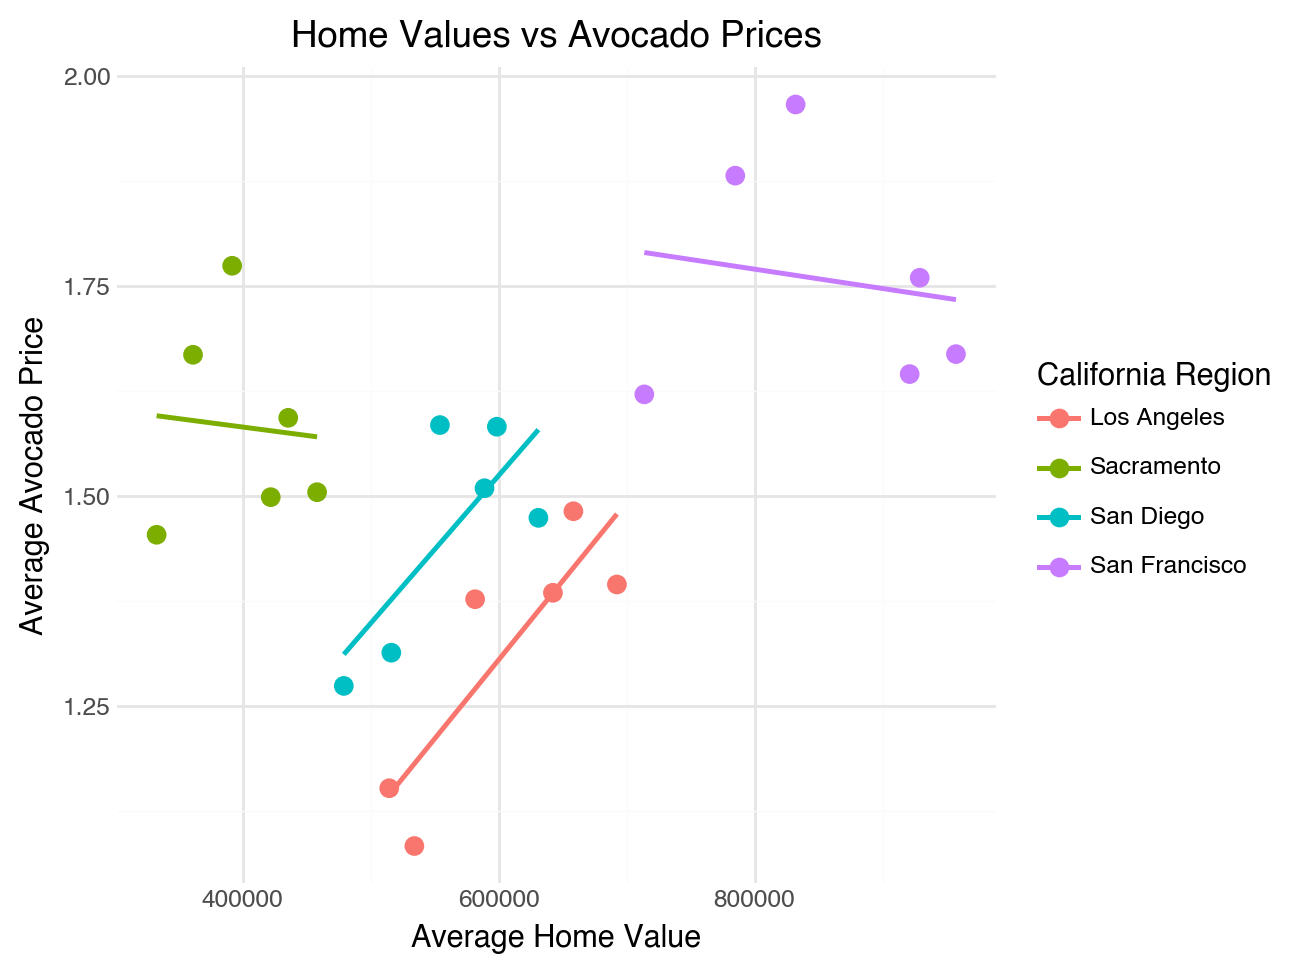

In [51]:
(ggplot(joined_df, aes(x="home_value", y="average_price", color="geography"))
+ geom_point(size=3)
+ geom_smooth(method="lm", se=False)
+ labs(x="Average Home Value", y="Average Avocado Price", color="California Region", title="Home Values vs Avocado Prices")
+ theme_minimal())

Home values were generally much higher in San Francisco than in the other California regions, and San Francisco also had the highest avocado prices. However, the relationship is not perfectly consistent across all regions, so higher home values do not always correspond to higher avocado prices.